# Imports

In [2]:
# Linear algebra
import numpy as np

# Dataframes
import pandas as pd

# Path
import os
data_path = os.path.join('..', 'data')

# Plotting
# import seaborn as sns
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Unify Predictions of Baseline Models with Test data 

## Load data

In [30]:
test_df = pd.read_pickle(os.path.join(data_path, "2_test_50_nn.pkl"))

mfc_df = pd.read_pickle(os.path.join(data_path, "2_50_mfc.pkl"))
exp_df = pd.read_pickle(os.path.join(data_path, "2_50_exp_harmonized.pkl"))
mfb_df = pd.read_pickle(os.path.join(data_path, "2_50_mfb.pkl"))

## Unify dataframes

In [32]:
# Unify test_df and vanilla_df
test_with_baseline_df = pd.concat([test_df, mfc_df, mfb_df, exp_df], axis=1)
test_with_baseline_df

,cluster,length (aa),query_gene,query_transcript,seq,amino_acid_seq,median,subject_transcript,average_pident,gene,transcript,median_float,mfc_prediction,mfc_accuracy,mfb_prediction,mfb_accuracy,exp_harmonized_prediction,exp_harmonized_accuracy
0,2191,932,ENSG00000134324,ENST00000396097,ATGAGCAGAGTGCAGACCATGAATTACGTGGGGCAGTTAGCCGGCC...,MSRVQTMNYVGQLAGQVFVTVKELYKGLNPATLSGCIDIIVIRQPN...,"(expr_pre75_90, expr_pre50_75, expr_pre75_90, ...",ENST00000261596,48.943442,ENSG00000134324,ENST00000396097,"(2.880000114440918, 1.5, 2.2899999618530273, 0...",ATGAGCAGAGTGCAGACCATGAACTACGTGGGCCAGCTGGCCGGCC...,0.457663,ATGAGCAGGGTGCAGACCATGAATTATGTGGGCCAGCTGGCCGGCC...,0.456592,ATGAGCAGAGTGCAGACCATGAACTACGTGGGCCAGCTGGCCGGCC...,0.457663
1,5329,249,ENSG00000172456,ENST00000634606,ATGTGGCTGGACCATCGAGCAGTCAGTCAAGTTAACAGGATCAATG...,MWLDHRAVSQVNRINETKHSVLQYVGGVMSVEMQAPKLLWLKENLR...,"(expr_pre25_50, expr_pre25_50, expr_pre25_50, ...",NaN,0.000000,ENSG00000172456,ENST00000634606,"(0.029999999329447746, 0.019999999552965164, 0...",ATGTGGCTGGACCACAGAGCCGTGAGCCAGGTGAACAGAATCAACG...,0.360000,ATGTGGCTGGACCACAGGGCCGTGTCCCAGGTGAACAGAATTAATG...,0.348000,ATGTGGCTGGACCACAGAGCCGTGAGCCAGGTGAACAGAATCAACG...,0.360000
2,7096,463,ENSG00000118495,ENST00000416623,ATGGCCACGTTCCCCTGCCAGTTATGTGGCAAGACGTTCCTCACCC...,MATFPCQLCGKTFLTLEKFTIHNYSHSRERPYKCVQPDCGKAFVSR...,"(expr_pre25_50, expr_pre50_75, expr_pre50_75, ...",ENST00000367405,18.618728,ENSG00000118495,ENST00000416623,"(0.1599999964237213, 0.27000001072883606, 0.86...",ATGGCCACCTTCCCCTGCCAGCTGTGCGGCAAGACCTTCCTGACCC...,0.521552,ATGGCCACCTTCCCCTGCCAGCTGTGCGGCAAGACCTTCCTGACCC...,0.521552,ATGGCCACCTTCCCCTGCCAGCTGTGCGGCAAGACCTTCCTGACCC...,0.521552
3,7405,432,ENSG00000257950,ENST00000550383,ATGGGGCAGGCGGGCTGCAAGGGGCTCTGCCTGTCGCTGTTCGACT...,MGQAGCKGLCLSLFDYKTEKYVIAKNKKVGLLYRLLQASILAYLVV...,NaN,ENST00000413302,38.319426,ENSG00000257950,ENST00000550383,NaN,ATGGGCCAGGCCGGCTGCAAGGGCCTGTGCCTGAGCCTGTTCGACT...,0.598152,ATGGGCCAGGCCGGCTGCAAGGGCCTGTGCCTGAGCCTGTTCGACT...,0.581986,ATGGGCCAGGCCGGCTGCAAGGGCCTGTGCCTGAGCCTGTTCGACT...,0.598152
4,5500,57,ENSG00000107669,ENST00000690706,ATGGCTTTCTGGGCGGGGGGTTCGCCCAGCGTCGTGGACTATTTCC...,MAFWAGGSPSVVDYFPSEDFYRCGYCKNESGSRSNGMWAHSMTVQD...,NaN,NaN,0.000000,ENSG00000107669,ENST00000690706,NaN,ATGGCCTTCTGGGCCGGCGGCAGCCCCAGCGTGGTGGACTACTTCC...,0.551724,ATGGCCTTCTGGGCCGGCGGCAGCCCCAGCGTGGTGGACTACTTCC...,0.551724,ATGGCCTTCTGGGCCGGCGGCAGCCCCAGCGTGGTGGACTACTTCC...,0.551724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15971,3560,726,ENSG00000081277,ENST00000367324,ATGAACCACTCGCCGCTCAAGACCGCCTTGGCGTACGAATGCTTCC...,MNHSPLKTALAYECFQDQDNSTLALPSDQKMKTGTSGRQRVQEQVM...,"(expr_pre75_90, expr_pre75_90, expr_pre25_50, ...",ENST00000331563,23.066762,ENSG00000081277,ENST00000367324,"(6.28000020980835, 4.480000019073486, 0.170000...",ATGAACCACAGCCCCCTGAAGACCGCCCTGGCCTACGAGTGCTTCC...,0.625860,ATGAATCATTCTCCACTGAAGACCGCCCTGGCCTACGAGTGCTTCC...,0.592847,ATGAACCACAGCCCCCTGAAGACCGCCCTGGCCTACGAGTGCTTCC...,0.625860
15972,3464,758,ENSG00000105298,ENST00000429344,ATGGGTCGGGACACACGCTCGCGCTCGCGGTCCGCGGGTCGCCGGG...,MGRDTRSRSRSAGRRGRRRQSQSGSRSRSRSHGRRNRRRREDEGRR...,"(expr_pre75_90, expr_pre75_90, expr_pre75_90, ...",NaN,0.000000,ENSG00000105298,ENST00000429344,"(10.079999923706055, 8.0600004196167, 6.925000...",ATGGGCAGAGACACCAGAAGCAGAAGCAGAAGCGCCGGCAGAAGAG...,0.682477,ATGGGCCGCGACACCAGGAGCAGGAGCAGGAGCGCCGGCCGCCGCG...,0.662714,ATGGGCCGGGACACCCGGAGCCGGAGCCGGAGCGCCGGCCGGCGGG...,0.737813
15973,2613,153,ENSG00000066468,ENST00000683035,ATGGTCAGCTGGGGTCGTTTCATCTGCCTGGTCGTGGTCACCATGG...,MVSWGRFICLVVVTMATLSLARPSFSLVEDTTLEPEEPPTKYQISQ...,NaN,ENST00000393637,21.568418,ENSG00000066468,ENST00000683035,NaN,ATGGTGAGCTGGGGCAGATTCATCTGCCTGGTGGTGGTGACCATGG...,0.441558,ATGGTGTCCTGGGGCCGCTTCATCTGCCTGGTGGTGGTGACCATGG...,0.454545,ATGGTGAGCTGGGGCAGATTCATCTGCCTGGTGGTGGTGACCATGG...,0.441558
15974,530,61,ENSG00000197892,ENST00000522355,ATGGGGGACTCCAAAGTGAAAGTGGCGGTGCGGATACGACCCATGA...,MGDSKVKVAVRIRPMNRRETDLHTKCVVDVDANKVILNPVNTNLS

## Save unified dataframe

In [33]:
test_with_baseline_df.to_pickle(os.path.join(data_path, "2_test_nn_with_baseline_50.pkl"))

# Graphs

In [3]:
test_with_baseline_df = pd.read_pickle(os.path.join(data_path, "2_test_nn_with_baseline_50.pkl"))

## Prediction Accuracy Histogram

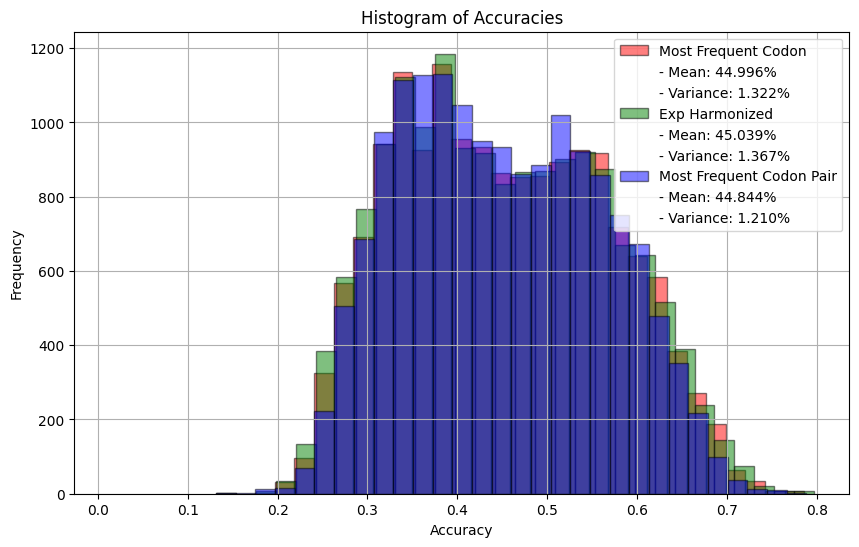

In [5]:
mfc_accuracies = test_with_baseline_df['mfc_accuracy']
exp_accuracies = test_with_baseline_df['exp_harmonized_accuracy']
mfb_accuracies = test_with_baseline_df['mfb_accuracy']

mean_mfc_accuracy = np.mean(mfc_accuracies)
mean_exp_accuracy = np.mean(exp_accuracies)
mean_mfb_accuracy = np.mean(mfb_accuracies)

variance_mfc_accuracy = np.var(mfc_accuracies)
variance_exp_accuracy = np.var(exp_accuracies)
variance_mfb_accuracy = np.var(mfb_accuracies)

plt.figure(figsize=(10, 6))

# Plot histogram for accuracies
plt.hist(mfc_accuracies, bins=30, color='red', edgecolor='black', alpha=0.5, label='Most Frequent Codon')
plt.axvline(mean_mfc_accuracy, color='blue', linestyle='dashed', linewidth=1, label=f'- Mean: {mean_mfc_accuracy * 100 :.3f}%', alpha=0)
plt.axvline(variance_mfc_accuracy, color='blue', linestyle='dashed', linewidth=1, label=f'- Variance: {variance_mfc_accuracy * 100 :.3f}%', alpha=0)


# Plot histogram for exp_accuracy
plt.hist(exp_accuracies, bins=30, color='green', edgecolor='black', alpha=0.5, label='Exp Harmonized')
plt.axvline(mean_exp_accuracy, color='blue', linestyle='dashed', linewidth=1, label=f'- Mean: {mean_exp_accuracy * 100 :.3f}%', alpha=0)
plt.axvline(variance_exp_accuracy, color='blue', linestyle='dashed', linewidth=1, label=f'- Variance: {variance_exp_accuracy * 100 :.3f}%', alpha=0)

# Plot histogram for bi_codon_accuracy
plt.hist(mfb_accuracies, bins=30, color='blue', edgecolor='black', alpha=0.5, label='Most Frequent Codon Pair')
plt.axvline(mean_mfb_accuracy, color='blue', linestyle='dashed', linewidth=1, label=f'- Mean: {mean_mfb_accuracy * 100 :.3f}%', alpha=0)
plt.axvline(variance_mfb_accuracy, color='blue', linestyle='dashed', linewidth=1, label=f'- Variance: {variance_mfb_accuracy * 100 :.3f}%', alpha=0)

plt.title('Histogram of Accuracies')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

**Exp Harmonized shows slight improvement, using codon pair reduces variance**

## Prediction Accuracy vs. Length

In [28]:
# sort by sequence lengths (in amino acids)
sorted_df = test_with_baseline_df.sort_values(by='length (aa)')

# Rename 'length (aa)' to 'length (nt)' and multiply values by 3
sorted_df = sorted_df.rename(columns={'length (aa)': 'length (nt)'})
sequence_lengths = sorted_df['length (nt)'].astype(int) * 3

# group by sequence lengths and calculate the average of the accuracy columns
grouped = sorted_df.groupby(sequence_lengths)
average_accuracies_per_length = grouped[['mfc_accuracy', 'mfb_accuracy', 'exp_harmonized_accuracy']].mean()


In [29]:
average_accuracies_per_length

,mfc_accuracy,mfb_accuracy,exp_harmonized_accuracy
length (nt),,,
33,0.750000,0.750000,0.750000
36,0.384615,0.384615,0.384615
39,0.364286,0.364286,0.364286
45,0.687500,0.625000,0.687500
51,0.666667,0.666667,0.666667
...,...,...,...
23904,0.614255,0.612498,0.614255
23907,0.614304,0.612547,0.631493
25449,0.608675,0.605375,0.608675


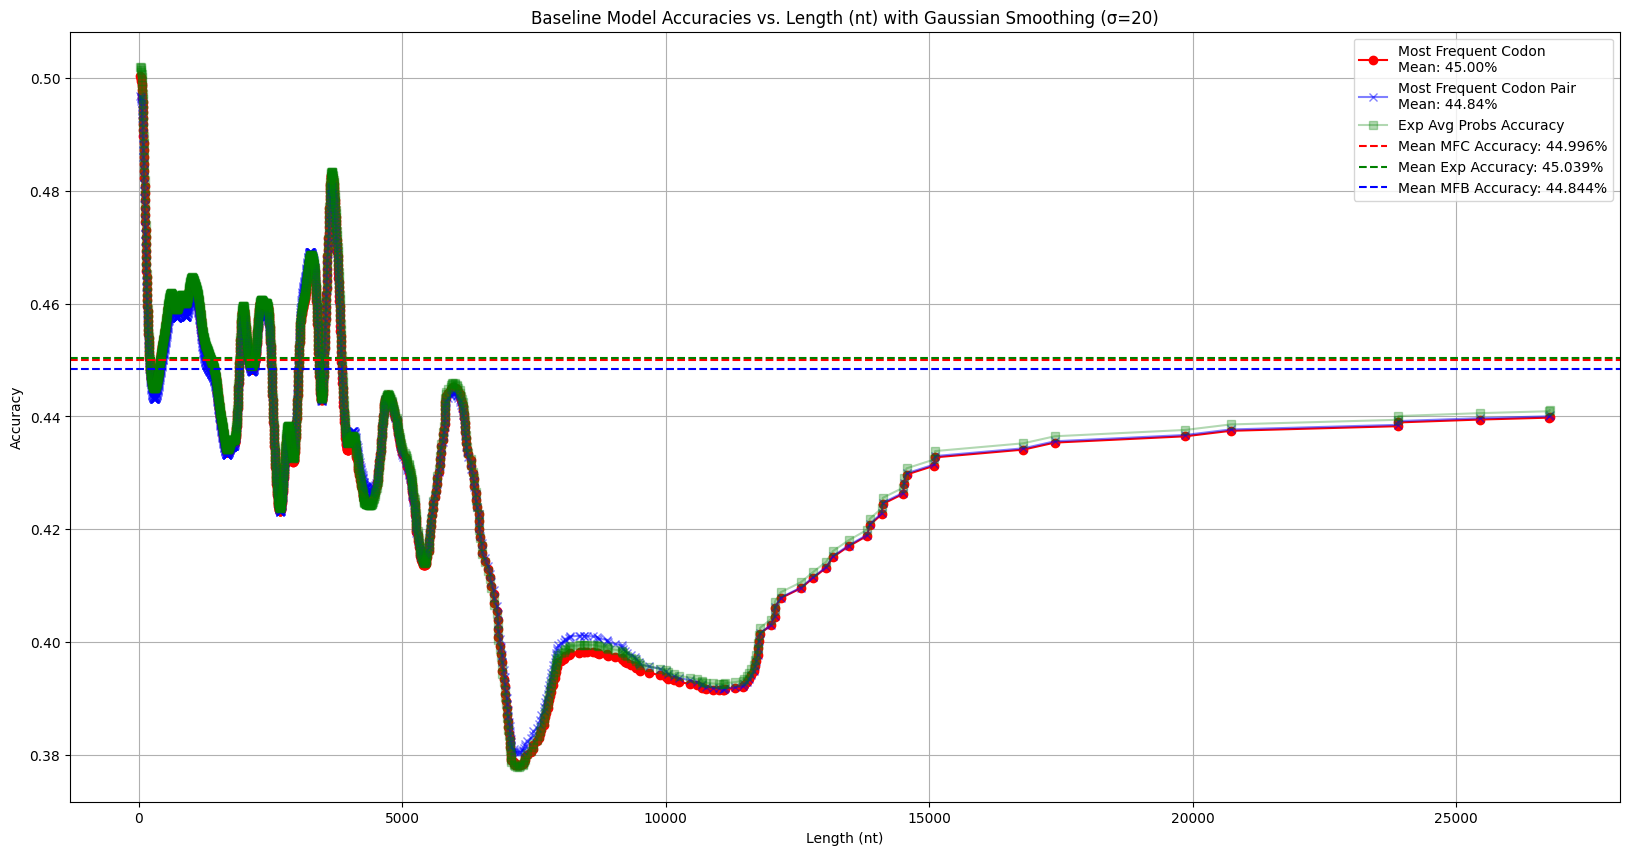

In [30]:
sgma = 20

# Apply Gaussian smoothing
smoothed_mfc_accuracy = gaussian_filter1d(average_accuracies_per_length['mfc_accuracy'], sigma=sgma)
smoothed_mfb_accuracy = gaussian_filter1d(average_accuracies_per_length['mfb_accuracy'], sigma=sgma)
smoothed_exp_accuracy = gaussian_filter1d(average_accuracies_per_length['exp_harmonized_accuracy'], sigma=sgma)

avg_mfc_accuracy = np.mean(test_with_baseline_df['mfc_accuracy'])
avg_mfb_accuracy = np.mean(test_with_baseline_df['mfb_accuracy'])
avg_exp_accuracy = np.mean(test_with_baseline_df['exp_harmonized_accuracy'])

plt.figure(figsize=(20, 10))

plt.plot(average_accuracies_per_length.index, smoothed_mfc_accuracy, marker='o', alpha=1, color='red', label=f'Most Frequent Codon\nMean: {avg_mfc_accuracy * 100 :.2f}%')
plt.plot(average_accuracies_per_length.index, smoothed_mfb_accuracy, marker='x', alpha=0.5, color='blue', label=f'Most Frequent Codon Pair\nMean: {avg_mfb_accuracy * 100 :.2f}%')
plt.plot(average_accuracies_per_length.index, smoothed_exp_accuracy, marker='s', alpha=0.3, color='green', label='Exp Avg Probs Accuracy')

# plot horizontal lines for the average accuracies
plt.axhline(avg_mfc_accuracy, color='r', linestyle='--', label=f'Mean MFC Accuracy: {avg_mfc_accuracy * 100 :.3f}%')
plt.axhline(avg_exp_accuracy, color='g', linestyle='--', label=f'Mean Exp Accuracy: {avg_exp_accuracy * 100 :.3f}%')
plt.axhline(avg_mfb_accuracy, color='b', linestyle='--', label=f'Mean MFB Accuracy: {avg_mfb_accuracy * 100 :.3f}%')

plt.title(f'Baseline Model Accuracies vs. Length (nt) with Gaussian Smoothing (σ={sgma})')
plt.xlabel('Length (nt)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Prediction Accuracy vs. Length Ranking

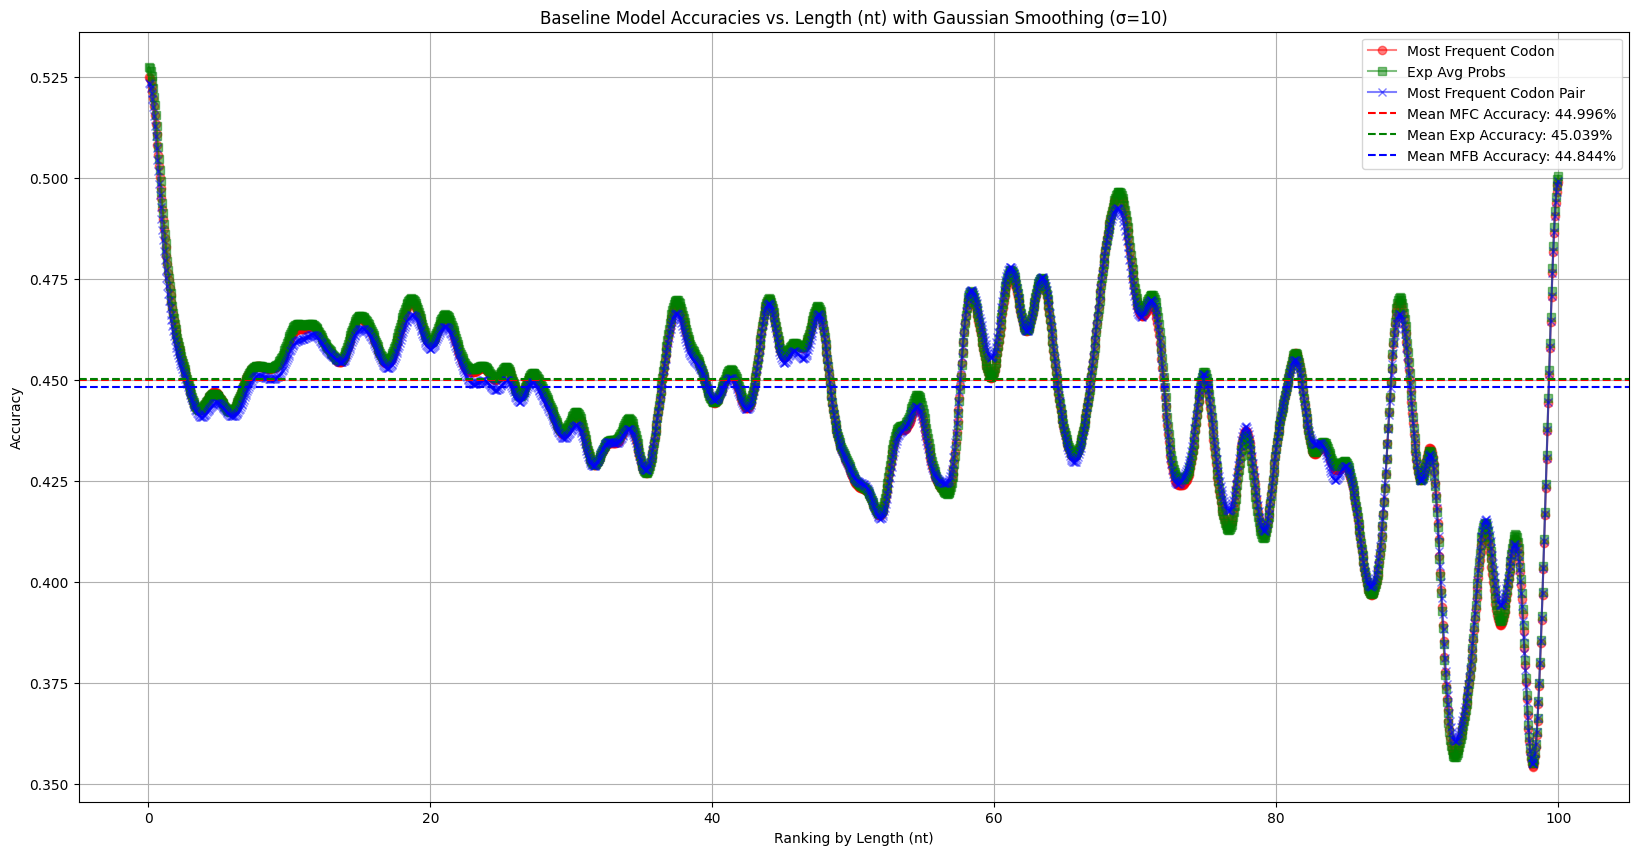

In [32]:
# Rank sequence lengths by percentages
ranked_lengths = pd.Series(average_accuracies_per_length.index).rank(pct=True)
ranked_lengths = ranked_lengths * 100

sgma = 10

# Apply Gaussian smoothing
smoothed_mfc_accuracy = gaussian_filter1d(average_accuracies_per_length['mfc_accuracy'], sigma=sgma)
smoothed_mfb_accuracy = gaussian_filter1d(average_accuracies_per_length['mfb_accuracy'], sigma=sgma)
smoothed_exp_accuracy = gaussian_filter1d(average_accuracies_per_length['exp_harmonized_accuracy'], sigma=sgma)

plt.figure(figsize=(20, 10))

plt.plot(ranked_lengths, smoothed_mfc_accuracy, marker='o', alpha=0.5, color='red', label='Most Frequent Codon')
plt.plot(ranked_lengths, smoothed_exp_accuracy, marker='s', alpha=0.5, color='green', label='Exp Avg Probs')
plt.plot(ranked_lengths, smoothed_mfb_accuracy, marker='x', alpha=0.5, color='blue', label='Most Frequent Codon Pair')

# plot horizontal lines for the average accuracies
plt.axhline(avg_mfc_accuracy, color='r', linestyle='--', label=f'Mean MFC Accuracy: {avg_mfc_accuracy * 100 :.3f}%')
plt.axhline(avg_exp_accuracy, color='g', linestyle='--', label=f'Mean Exp Accuracy: {avg_exp_accuracy * 100 :.3f}%')
plt.axhline(avg_mfb_accuracy, color='b', linestyle='--', label=f'Mean MFB Accuracy: {avg_mfb_accuracy * 100 :.3f}%')


plt.title(f'Baseline Model Accuracies vs. Length (nt) with Gaussian Smoothing (σ={sgma})')
plt.xlabel('Ranking by Length (nt)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Prediction Accuracy vs. Average Pident

In [33]:
# sort by sequence average pident
sorted_df = test_with_baseline_df.sort_values(by='average_pident')

average_pidents = sorted_df['average_pident']

# group by sequence lengths and calculate the average of the accuracy columns
grouped = sorted_df.groupby(average_pidents)
average_accuracies_per_pident = grouped[['mfc_accuracy', 'mfb_accuracy', 'exp_harmonized_accuracy']].mean()
                              #'exp_harmonized_majority_vote_accuracy', 'exp_harmonized_avg_probs_accuracy']].mean()


In [34]:
average_accuracies_per_pident

,mfc_accuracy,mfb_accuracy,exp_harmonized_accuracy
average_pident,,,
0.000000,0.437016,0.435705,0.437390
0.474389,0.560386,0.561077,0.560386
0.683181,0.283397,0.290653,0.283397
0.846321,0.294746,0.308549,0.294746
1.247658,0.495636,0.480050,0.495636
...,...,...,...
93.975904,0.285714,0.297619,0.285714
94.664372,0.448454,0.453608,0.448454
95.833000,0.360825,0.350515,0.356701


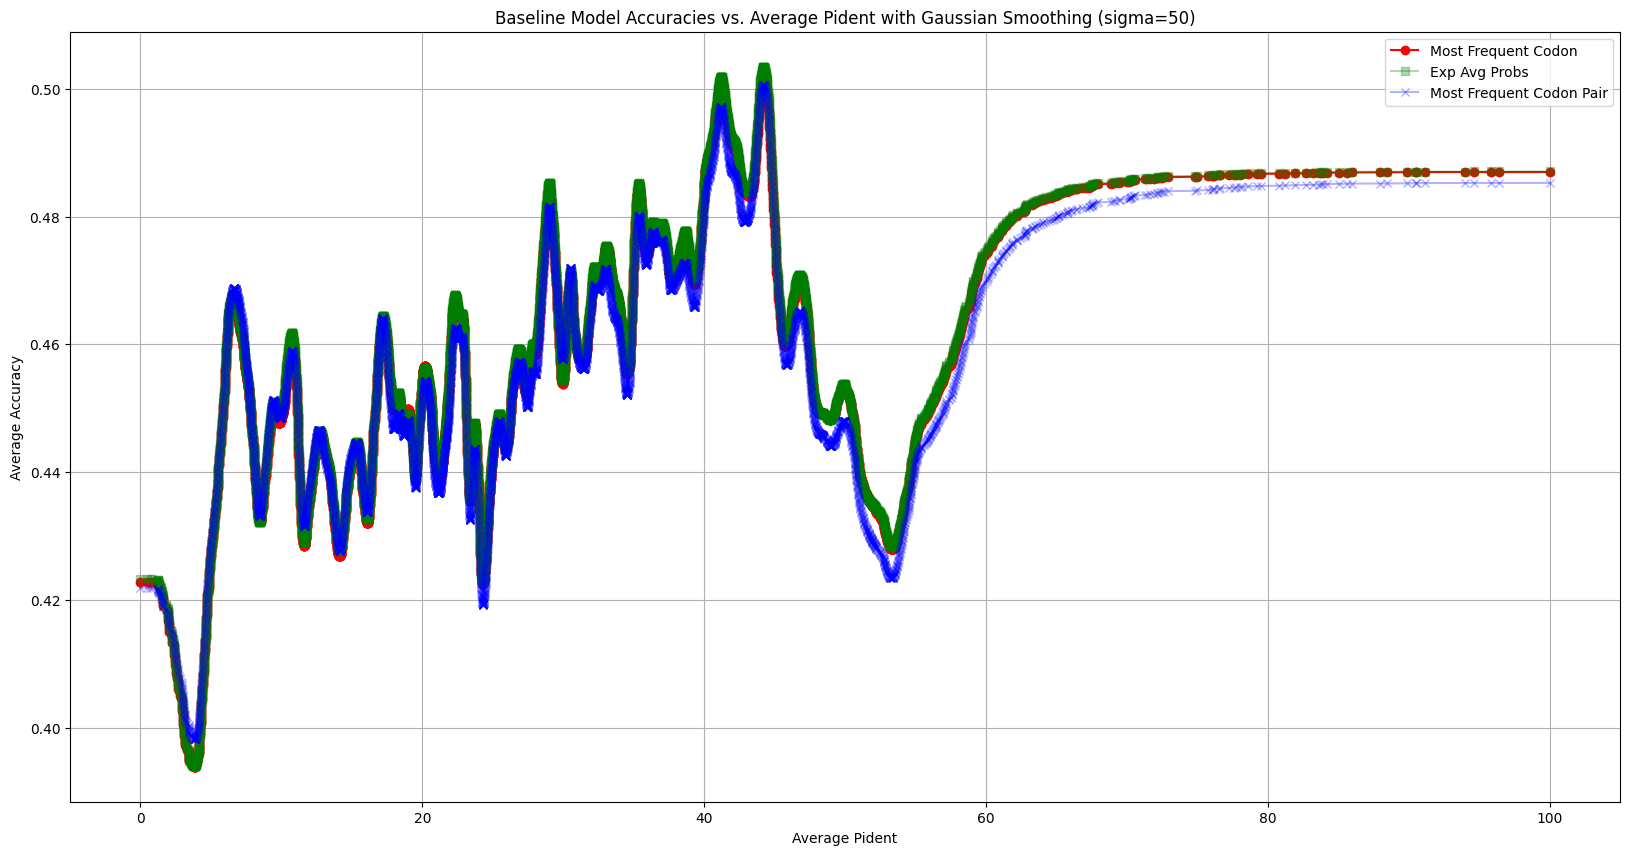

In [35]:
# Apply Gaussian smoothing
sgma = 50

smoothed_mfc_accuracy = gaussian_filter1d(average_accuracies_per_pident['mfc_accuracy'], sigma=sgma)
smoothed_mfb_accuracy = gaussian_filter1d(average_accuracies_per_pident['mfb_accuracy'], sigma=sgma)
smoothed_exp_accuracy = gaussian_filter1d(average_accuracies_per_pident['exp_harmonized_accuracy'], sigma=sgma)

plt.figure(figsize=(20, 10))

plt.plot(average_accuracies_per_pident.index, smoothed_mfc_accuracy, marker='o', alpha=1, color='red', label='Most Frequent Codon')
plt.plot(average_accuracies_per_pident.index, smoothed_exp_accuracy, marker='s', alpha=0.3, color='green', label='Exp Avg Probs')
plt.plot(average_accuracies_per_pident.index, smoothed_mfb_accuracy, marker='x', alpha=0.3, color='blue', label='Most Frequent Codon Pair')

plt.title(f"Baseline Model Accuracies vs. Average Pident with Gaussian Smoothing (sigma={sgma})")
plt.xlabel('Average Pident')
plt.ylabel('Average Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Prediction accuracy vs. mean expression value

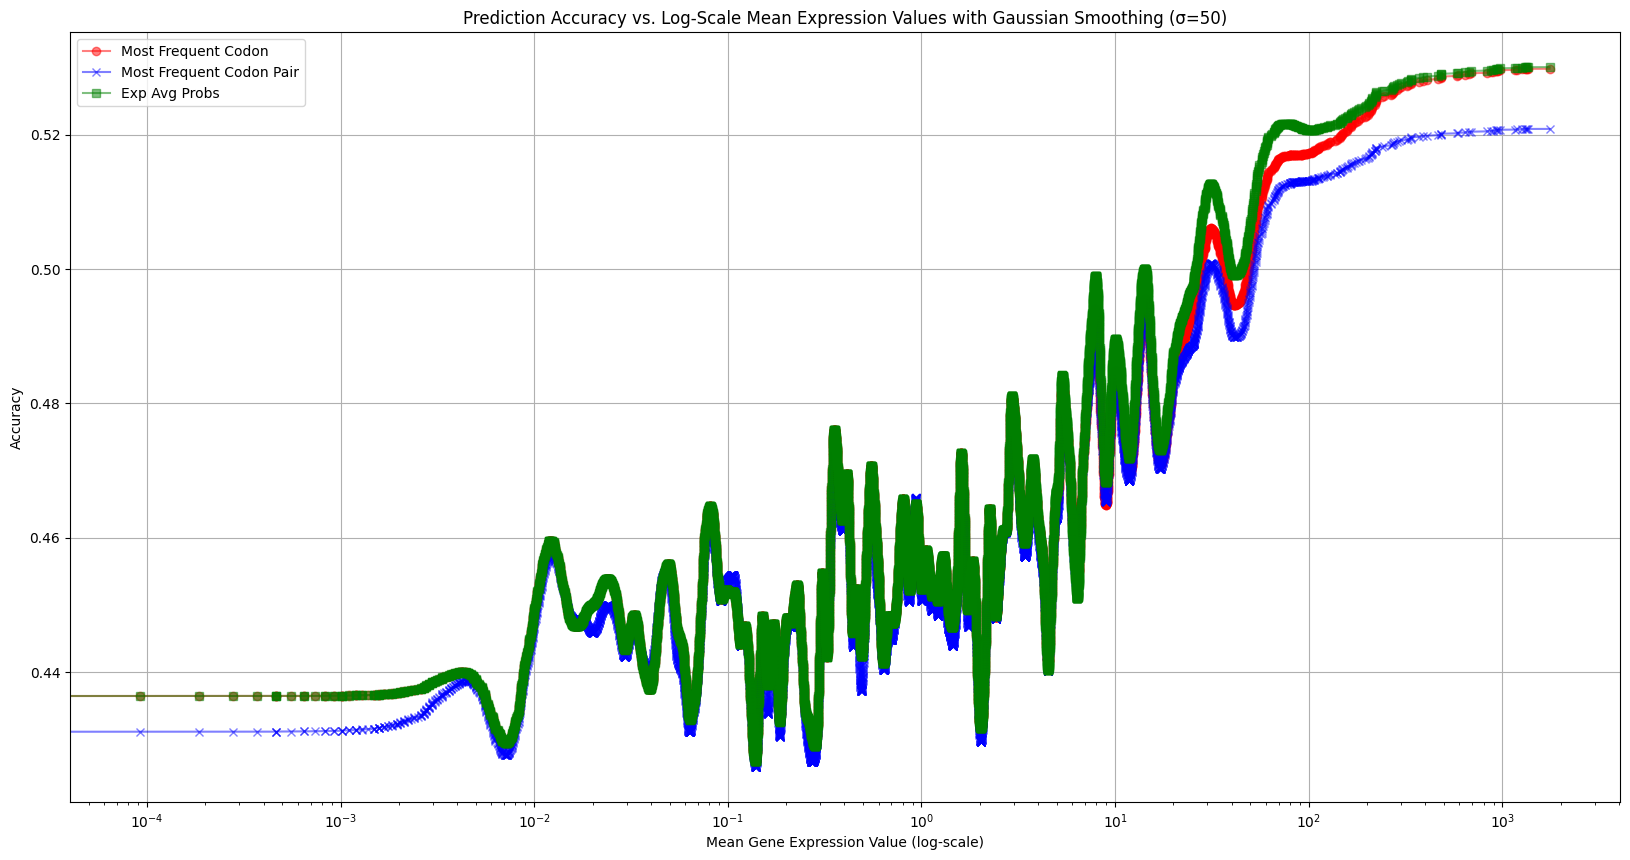

In [8]:
# Drop rows with NaN values in 'median_float'
temp_df = test_with_baseline_df.dropna(subset=['median_float']).copy()

# Extract mean of each tuple in the 'median' column
temp_df.loc[:, 'mean_expression'] = temp_df['median_float'].apply(lambda x: np.mean([float(v) for v in x]) if isinstance(x, tuple) else x)

# sort temp_df by the mean of the 'median_float' column
sorted_df = temp_df.sort_values('mean_expression')

# Group by 'median_float' and calculate the average of the accuracy columns
grouped_by_mean_expression = sorted_df.groupby('mean_expression')
average_accuracies_per_mean_expression = grouped_by_mean_expression[['mfc_accuracy', 'mfb_accuracy', 'exp_harmonized_accuracy']].mean()

# Apply Gaussian smoothing
sgma = 50

smoothed_mfc_accuracy = gaussian_filter1d(average_accuracies_per_mean_expression['mfc_accuracy'], sigma=sgma)
smoothed_mfb_accuracy = gaussian_filter1d(average_accuracies_per_mean_expression['mfb_accuracy'], sigma=sgma)
smoothed_exp_accuracy = gaussian_filter1d(average_accuracies_per_mean_expression['exp_harmonized_accuracy'], sigma=sgma)

# Plot the accuracies vs. mean 'median_float' values
plt.figure(figsize=(20, 10))

plt.plot(average_accuracies_per_mean_expression.index, smoothed_mfc_accuracy, marker='o', alpha=0.5, color='red', label='Most Frequent Codon')
plt.plot(average_accuracies_per_mean_expression.index, smoothed_mfb_accuracy, marker='x', alpha=0.5, color='blue', label='Most Frequent Codon Pair')
plt.plot(average_accuracies_per_mean_expression.index, smoothed_exp_accuracy, marker='s', alpha=0.5, color='green', label='Exp Avg Probs')

plt.title(f'Prediction Accuracy vs. Log-Scale Mean Expression Values with Gaussian Smoothing (σ={sgma})')
plt.xlabel('Mean Gene Expression Value (log-scale)')
plt.xscale('log')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Prediction Accuracy vs. Mean Expression Percentile

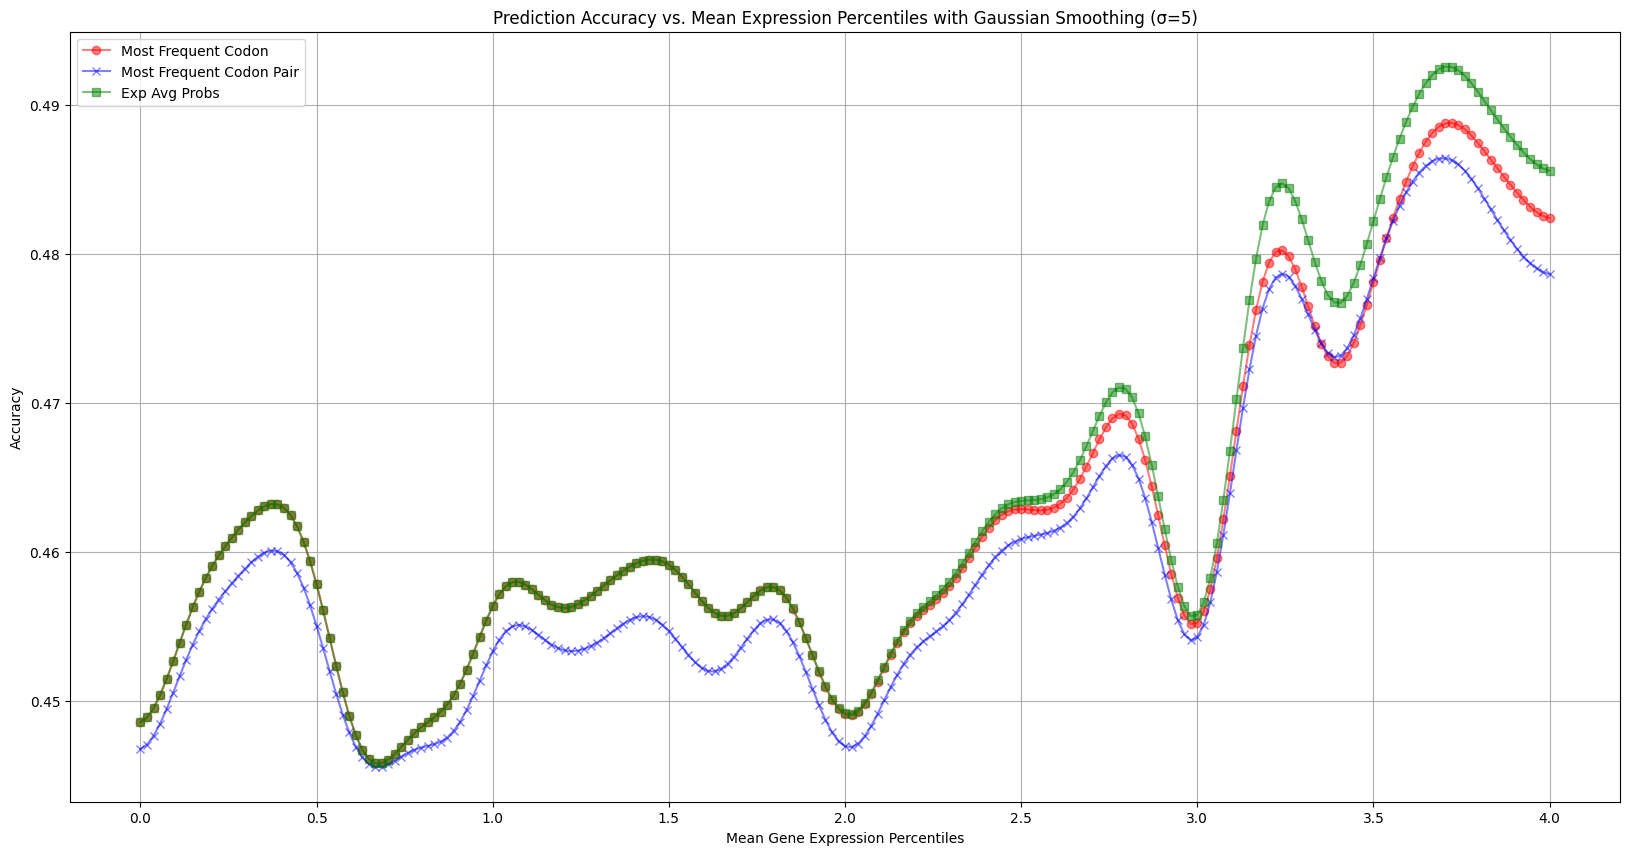

In [147]:
# Drop rows with NaN values in 'median_float'
temp_df = test_with_baseline_df.dropna(subset=['median']).copy()

# Replace 'median' string values with their index integer values
expr_labels = ['expr_low25', 'expr_pre25_50', 'expr_pre50_75', 'expr_pre75_90', 'expr_top10']
temp_df.loc[:, 'median'] = temp_df['median'].apply(lambda x: [expr_labels.index(v) for v in x] if isinstance(x, tuple) else x)

# Extract mean of each list in the 'median' column
temp_df.loc[:, 'mean_expression'] = temp_df['median'].apply(lambda x: np.mean(x) if isinstance(x, list) else x)

# sort temp_df by the mean of the 'median_float' column
sorted_df = temp_df.sort_values('mean_expression')

# Group by 'median_float' and calculate the average of the accuracy columns
grouped_by_mean_expression = sorted_df.groupby('mean_expression')
average_accuracies_per_mean_expression = grouped_by_mean_expression[['mfc_accuracy', 'mfb_accuracy', 'exp_harmonized_accuracy']].mean()

# Apply Gaussian smoothing
sgma = 5

smoothed_mfc_accuracy = gaussian_filter1d(average_accuracies_per_mean_expression['mfc_accuracy'], sigma=sgma)
smoothed_mfb_accuracy = gaussian_filter1d(average_accuracies_per_mean_expression['mfb_accuracy'], sigma=sgma)
smoothed_exp_accuracy = gaussian_filter1d(average_accuracies_per_mean_expression['exp_harmonized_accuracy'], sigma=sgma)

# Plot the accuracies vs. mean 'median_float' values
plt.figure(figsize=(20, 10))

plt.plot(average_accuracies_per_mean_expression.index, smoothed_mfc_accuracy, marker='o', alpha=0.5, color='red', label='Most Frequent Codon')
plt.plot(average_accuracies_per_mean_expression.index, smoothed_mfb_accuracy, marker='x', alpha=0.5, color='blue', label='Most Frequent Codon Pair')
plt.plot(average_accuracies_per_mean_expression.index, smoothed_exp_accuracy, marker='s', alpha=0.5, color='green', label='Exp Avg Probs')

plt.title(f'Prediction Accuracy vs. Mean Expression Percentiles with Gaussian Smoothing (σ={sgma})')
plt.xlabel('Mean Gene Expression Percentiles')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Prediction Accuracy vs. Expression Value Mixed Modelling

**Center and Standardize Median Float Values, Replace Median Percentile Strings with Integers.**

In [11]:
# Drop rows with NaN values in 'median_float'
temp_df = test_with_baseline_df.dropna(subset=['median_float']).copy()

# Replace 'median' string values with their index integer values
expr_labels = ['expr_low25', 'expr_pre25_50', 'expr_pre50_75', 'expr_pre75_90', 'expr_top10']
temp_df.loc[:, 'median'] = temp_df['median'].apply(lambda x: [expr_labels.index(v) for v in x] if isinstance(x, tuple) else x)

# Calculate the mean and standard deviation for each index in the 'median_float' tuples
median_float_df = temp_df['median_float'].apply(pd.Series)
mean_values = median_float_df.mean()
std_values = median_float_df.std()

# Center and Standardize the 'median_float' tuples
temp_df['median_float'] = temp_df['median_float'].apply(
    lambda x: tuple((v - mean_values[i]) / std_values[i] if std_values[i] != 0 else 0 for i, v in enumerate(x))
)

**Explode 'median' and 'median_float' list-like values.**

In [12]:
# Reset index to avoid duplicate labels
temp_df_reset = temp_df.reset_index(drop=True)

# Explode the rows using a single 'median' and corresponding 'median_float' value for each row
exploded_df = temp_df_reset.apply(lambda x: x.explode() if x.name in ['median', 'median_float'] else x)

# Add a column for the index of each value in the original lists
exploded_df['tissue_index'] = exploded_df.groupby(level=0).cumcount()

# sort exploded_df by the 'tissue_index' column
sorted_df = exploded_df.sort_values('tissue_index')

### Graph Accuracy vs. Expression Values per Tissue Site

**Take the accuracy mean of rows with same-tissue same-expression value.**

In [13]:
# Group by 'tissue_index' and 'median_float' and calculate the average of the accuracy columns
grouped_by_index_and_expression = sorted_df.groupby(['tissue_index', 'median_float'])
average_accuracies_per_index_and_expression = grouped_by_index_and_expression[['mfc_accuracy', 'mfb_accuracy', 'exp_harmonized_accuracy']].mean().reset_index()

In [14]:
# Tissue Site Detail Ids
tissueSiteDetailId = ('Adipose_Subcutaneous',
 'Adipose_Visceral_Omentum',
 'Adrenal_Gland',
 'Artery_Aorta',
 'Artery_Coronary',
 'Artery_Tibial',
 'Bladder',
 'Brain_Amygdala',
 'Brain_Anterior_cingulate_cortex_BA24',
 'Brain_Caudate_basal_ganglia',
 'Brain_Cerebellar_Hemisphere',
 'Brain_Cerebellum',
 'Brain_Cortex',
 'Brain_Frontal_Cortex_BA9',
 'Brain_Hippocampus',
 'Brain_Hypothalamus',
 'Brain_Nucleus_accumbens_basal_ganglia',
 'Brain_Putamen_basal_ganglia',
 'Brain_Spinal_cord_cervical_c-1',
 'Brain_Substantia_nigra',
 'Breast_Mammary_Tissue',
 'Cells_EBV-transformed_lymphocytes',
 'Cells_Cultured_fibroblasts',
 'Cervix_Ectocervix',
 'Cervix_Endocervix',
 'Colon_Sigmoid',
 'Colon_Transverse',
 'Esophagus_Gastroesophageal_Junction',
 'Esophagus_Mucosa',
 'Esophagus_Muscularis',
 'Fallopian_Tube',
 'Heart_Atrial_Appendage',
 'Heart_Left_Ventricle',
 'Kidney_Cortex',
 'Kidney_Medulla',
 'Liver',
 'Lung',
 'Minor_Salivary_Gland',
 'Muscle_Skeletal',
 'Nerve_Tibial',
 'Ovary',
 'Pancreas',
 'Pituitary',
 'Prostate',
 'Skin_Not_Sun_Exposed_Suprapubic',
 'Skin_Sun_Exposed_Lower_leg',
 'Small_Intestine_Terminal_Ileum',
 'Spleen',
 'Stomach',
 'Testis',
 'Thyroid',
 'Uterus',
 'Vagina',
 'Whole_Blood')

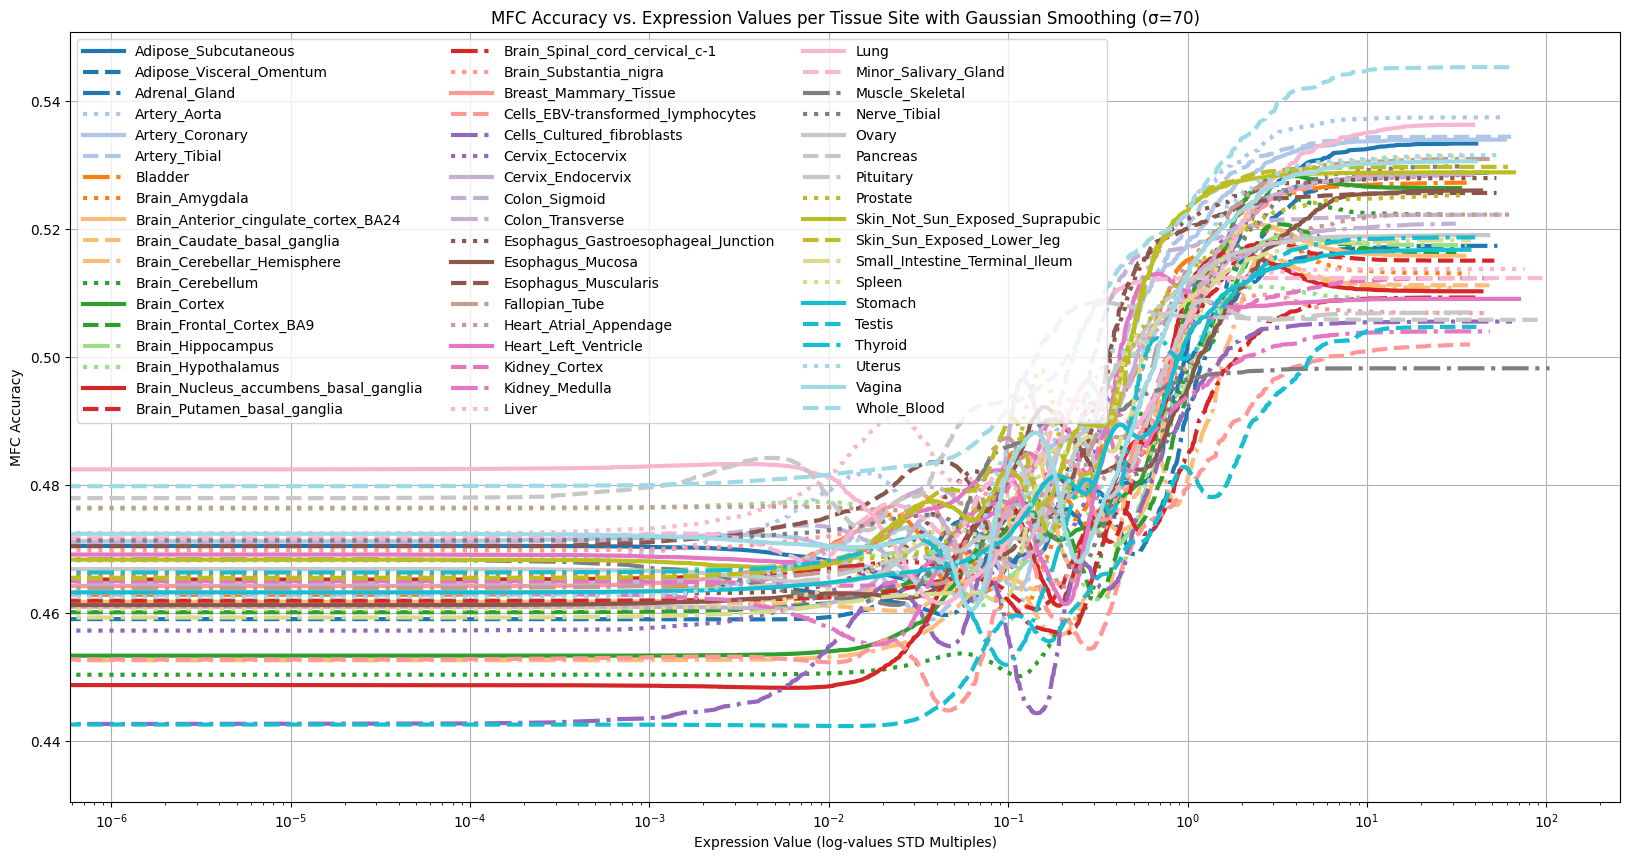

In [24]:
# Plot the graph for the exploded values with Gaussian smoothing
plt.figure(figsize=(20, 10))
sgma = 70  # Standard deviation for Gaussian kernel

# Get a colormap with a sufficient number of unique colors
cmap = plt.get_cmap('tab20', len(tissueSiteDetailId))

# Line styles
line_styles = ['solid', 'dashed', 'dashdot', 'dotted']

for idx, tissue in enumerate(tissueSiteDetailId):
    subset = average_accuracies_per_index_and_expression[average_accuracies_per_index_and_expression['tissue_index'] == idx]
    smoothed_accuracy = gaussian_filter1d(subset['mfc_accuracy'], sigma=sgma)
    line_style = line_styles[idx % len(line_styles)]
    plt.plot(subset['median_float'], smoothed_accuracy, label=tissue, alpha=1, color=cmap(idx), linestyle=line_style, linewidth=3)

plt.legend(loc='upper left', ncol=3, handlelength=3)
plt.title(f'MFC Accuracy vs. Expression Values per Tissue Site with Gaussian Smoothing (σ={sgma})')
plt.xlabel('Expression Value (log-values STD Multiples)')
plt.xscale('log')
plt.ylabel('MFC Accuracy')
plt.grid(True)
plt.show()

### Graph Accuracy vs. Expression Values

**Take the accuracy mean of rows with same expression value.**

In [ ]:
# Group by 'tissue_index' and 'median_float' and calculate the average of the accuracy columns
grouped_by_expression = sorted_df.groupby(['median_float'])
average_accuracies_per_expression = grouped_by_expression[['mfc_accuracy', 'mfb_accuracy', 'exp_harmonized_accuracy']].mean().reset_index()

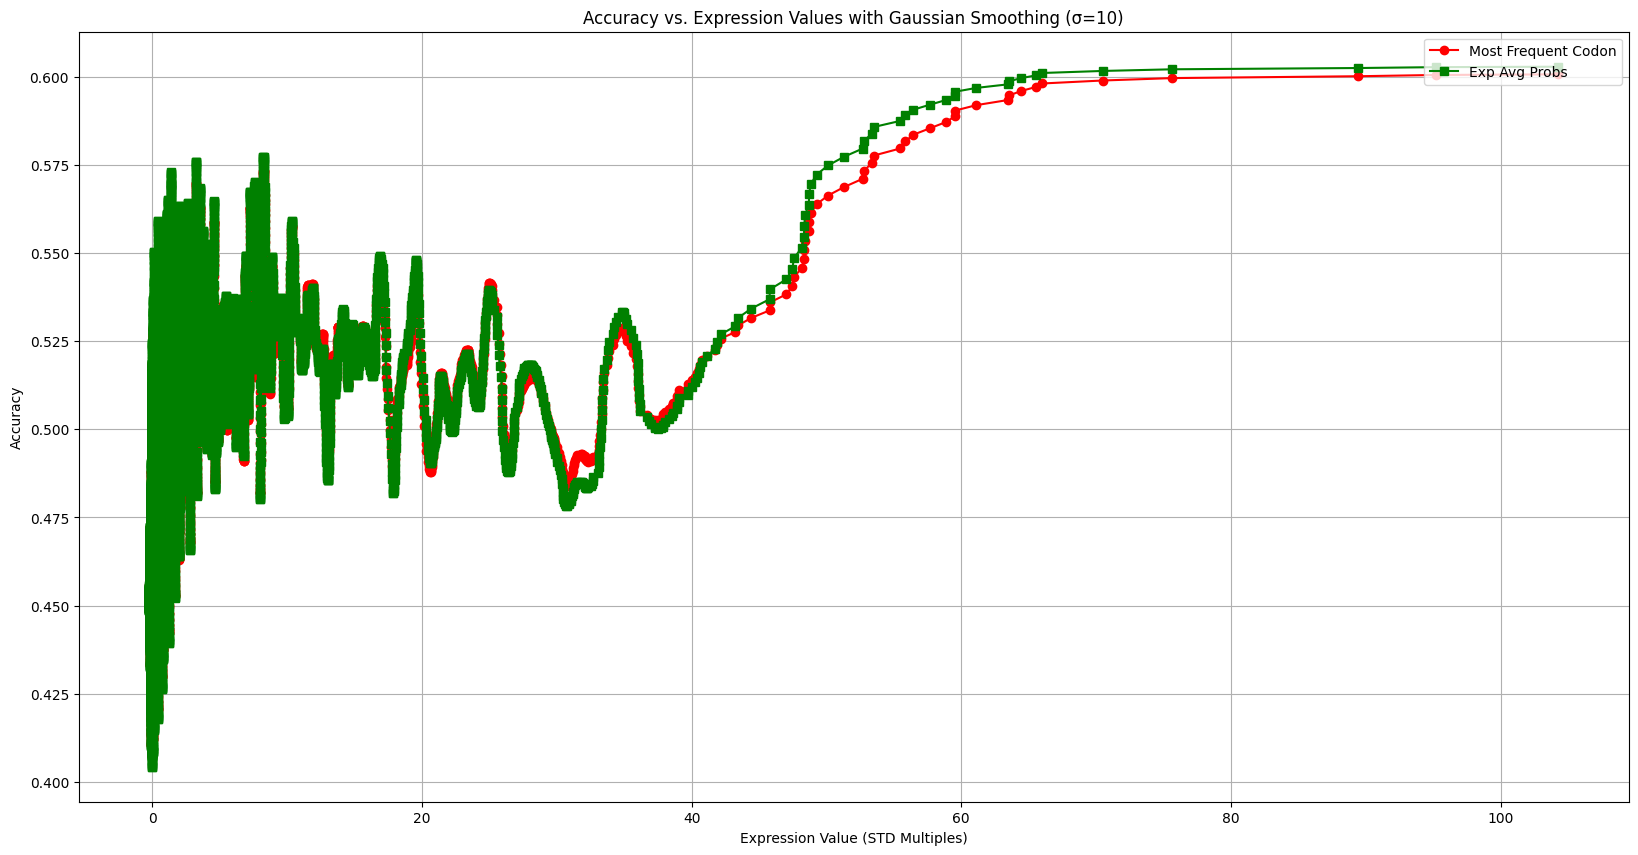

In [181]:
# Apply Gaussian smoothing
sgma = 10  # Standard deviation for Gaussian kernel

smoothed_mfc_accuracy = gaussian_filter1d(average_accuracies_per_expression['mfc_accuracy'], sigma=sgma)
smoothed_mfb_accuracy = gaussian_filter1d(average_accuracies_per_expression['mfb_accuracy'], sigma=sgma)
smoothed_exp_accuracy = gaussian_filter1d(average_accuracies_per_expression['exp_harmonized_accuracy'], sigma=sgma)

# Plot the graph for the exploded values with Gaussian smoothing
plt.figure(figsize=(20, 10))

plt.plot(average_accuracies_per_expression['median_float'], smoothed_mfc_accuracy, marker='o', alpha=1, color='red', label='Most Frequent Codon')
plt.plot(average_accuracies_per_expression['median_float'], smoothed_exp_accuracy, marker='s', alpha=1, color='green', label='Exp Avg Probs')
# plt.plot(average_accuracies_per_expression['median_float'], smoothed_mfb_accuracy, marker='x', alpha=0.5, color='blue', label='Most Frequent Codon Pair')

plt.legend(loc='upper right', ncol=1)
plt.title(f'Accuracy vs. Expression Values with Gaussian Smoothing (σ={sgma})')
plt.xlabel('Expression Value (STD Multiples)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

### Graph Accuracy vs. Expression Category Integer per Tissue Site

**Take the accuracy mean of rows with same-tissue same-expression category integer.**

In [ ]:
# Group by 'tissue_index' and 'median' and calculate the average of the accuracy columns
grouped_by_index_and_expression_perc = sorted_df.groupby(['tissue_index', 'median'])
average_accuracies_per_index_and_expression_perc = grouped_by_index_and_expression_perc[['mfc_accuracy', 'mfb_accuracy', 'exp_harmonized_accuracy']].mean().reset_index()

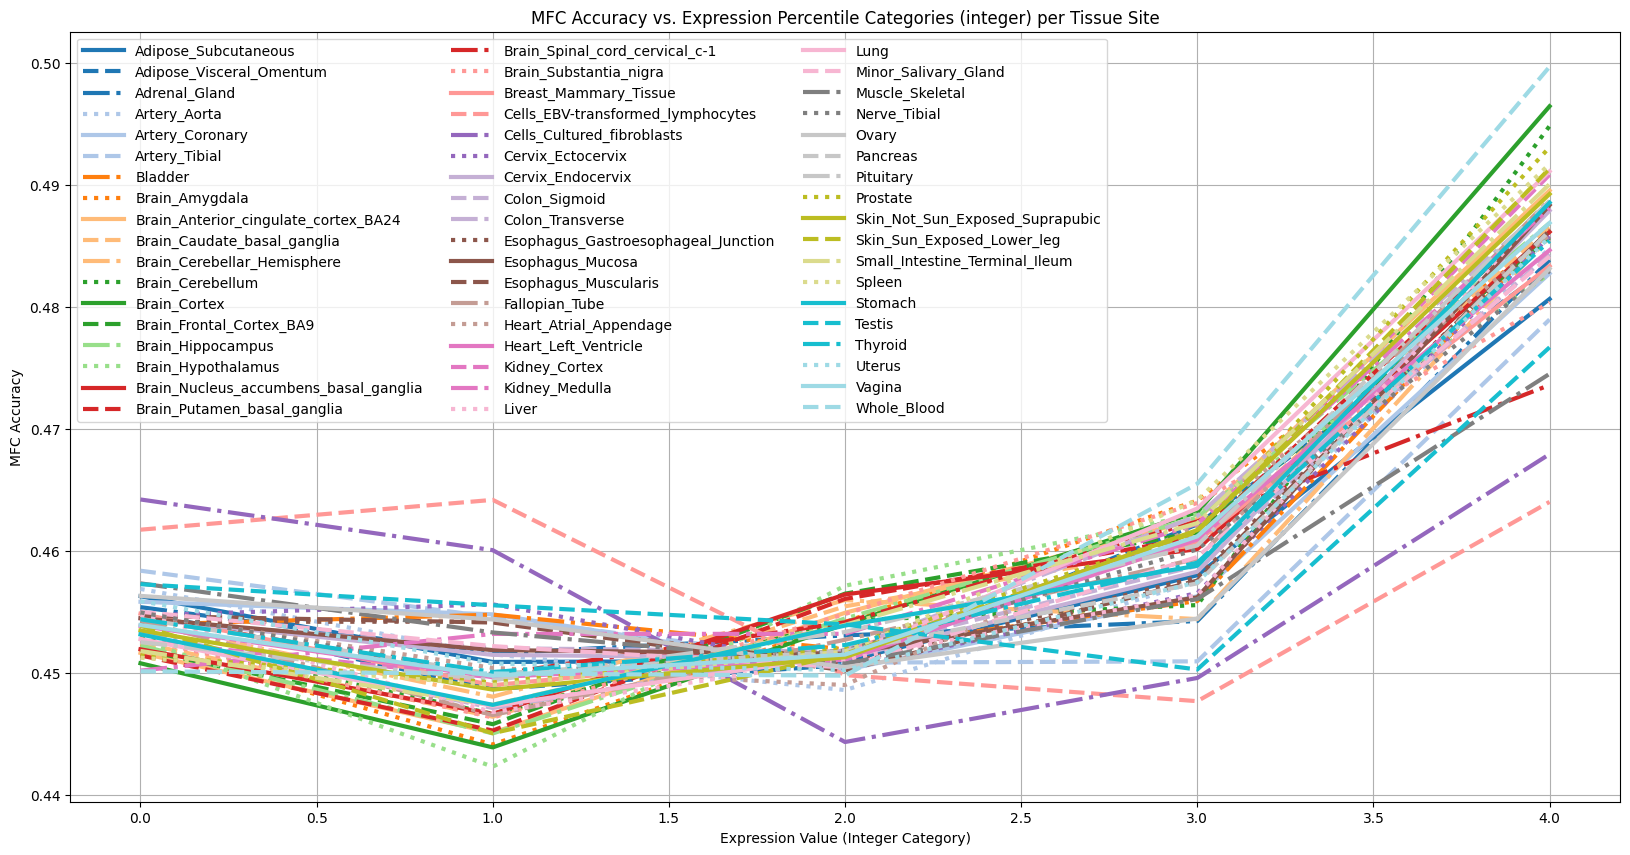

In [ ]:
plt.style.use('default')

# Plot the graph for the exploded values without Gaussian smoothing
plt.figure(figsize=(20, 10))

# Get a colormap
cmap = plt.get_cmap('tab20', len(tissueSiteDetailId))

# Line styles
line_styles = ['solid', 'dashed', 'dashdot', 'dotted']

for idx, tissue in enumerate(tissueSiteDetailId):
    subset = average_accuracies_per_index_and_expression_perc[average_accuracies_per_index_and_expression_perc['tissue_index'] == idx]
    line_style = line_styles[idx % len(line_styles)]
    plt.plot(subset['median'], subset['mfc_accuracy'], label=tissue, alpha=1, color=cmap(idx), linestyle=line_style, linewidth=3)

plt.legend(loc='upper left', ncol=3, handlelength=3)  # Adjust handlelength and handleheight
plt.title('MFC Accuracy vs. Expression Percentile Categories (integer) per Tissue Site')
plt.xlabel('Expression Value (Integer Category)')
plt.ylabel('MFC Accuracy')
plt.grid(True)
plt.show()


### Graph Accuracy vs. Expression Category Integer

**Take the accuracy mean of rows with same expression-percentile integer.**

In [ ]:
# Group by 'tissue_index' and 'median' and calculate the average of the accuracy columns
grouped_by_expression_perc = sorted_df.groupby(['median'])
average_accuracies_per_expression_perc = grouped_by_expression_perc[['mfc_accuracy', 'mfb_accuracy', 'exp_harmonized_accuracy']].mean().reset_index()

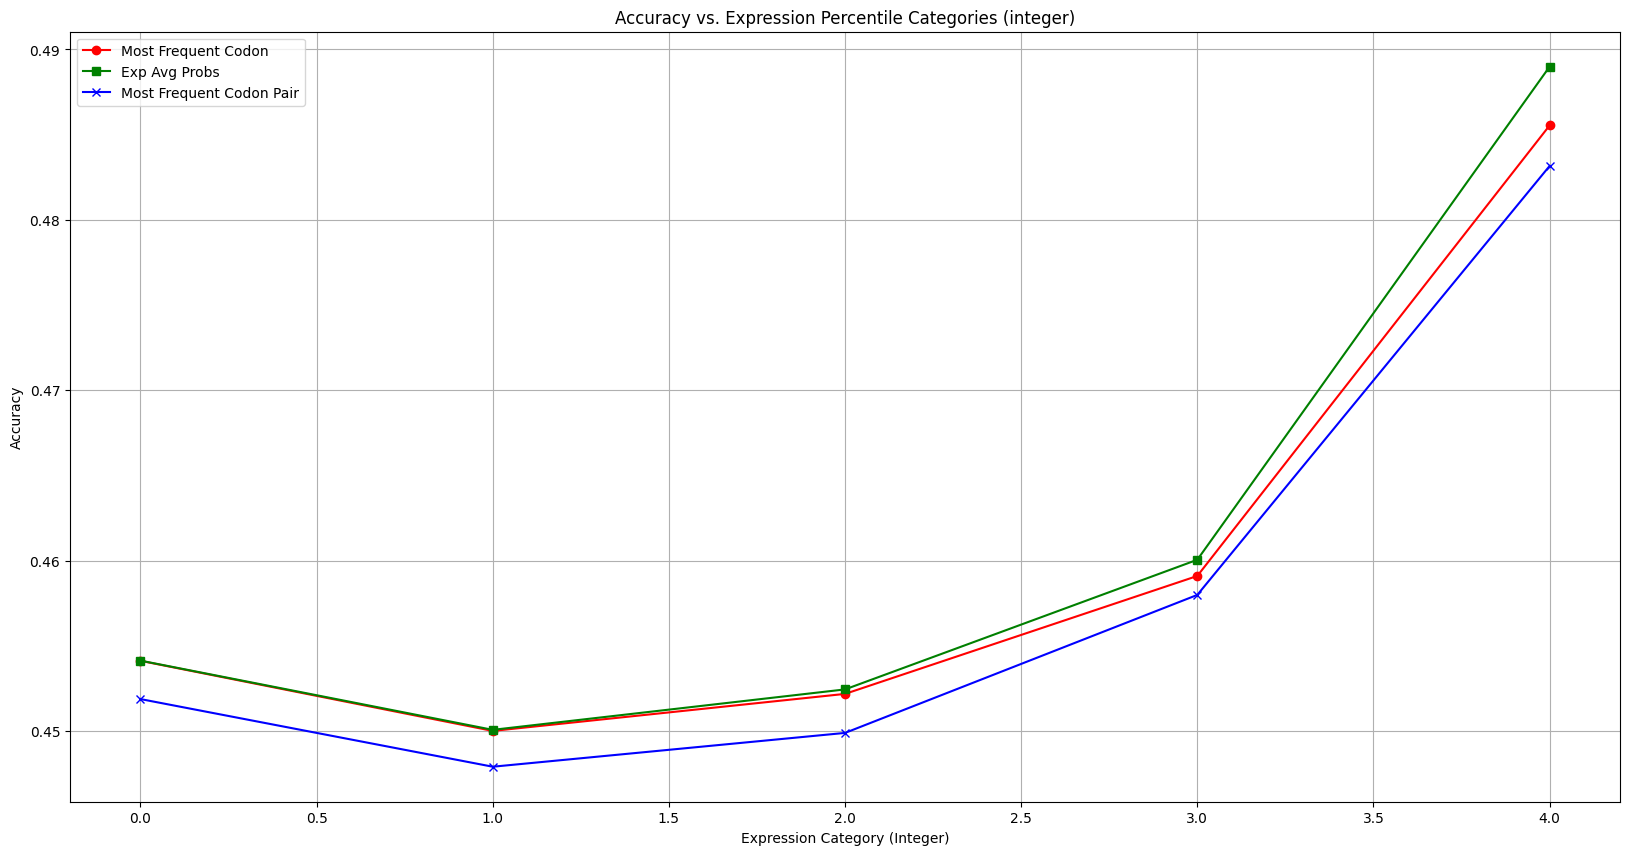

In [47]:
plt.style.use('default')

# Plot the graph for the exploded values without Gaussian smoothing
plt.figure(figsize=(20, 10))

plt.plot(average_accuracies_per_expression_perc['median'], average_accuracies_per_expression_perc['mfc_accuracy'], marker='o', alpha=1, color='red', label='Most Frequent Codon')
plt.plot(average_accuracies_per_expression_perc['median'], average_accuracies_per_expression_perc['exp_harmonized_accuracy'], marker='s', alpha=1, color='green', label='Exp Avg Probs')
plt.plot(average_accuracies_per_expression_perc['median'], average_accuracies_per_expression_perc['mfb_accuracy'], marker='x', alpha=1, color='blue', label='Most Frequent Codon Pair')
plt.legend(loc='upper left', ncol=1)  # Adjust ncol to the desired number of columns
plt.title('Accuracy vs. Expression Percentile Categories (integer)')
plt.xlabel('Expression Category (Integer)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()